<a href="https://colab.research.google.com/github/leohermansson/NBA-GOATS-Image-Classification/blob/main/Image_Classification_NBA_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
pip install bing-image-downloader

In [23]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from bing_image_downloader import downloader
import os
from sklearn.model_selection import train_test_split
import glob
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import numpy as np
import torch.optim as optim

In [5]:
# Set random seeds for reproducibility

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
players = ["Stephen Curry", "Michael Jordan", "LeBron James", "Tim Duncan","Shaquille O'Neal"]

for player in players:
    downloader.download(player, limit=50)

In [9]:
def organize_dataset(source_dir='/content/drive/MyDrive/PyTorch/dataset', target_dir='/content/drive/MyDrive/PyTorch/organized_data',
                     train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Organize images into train/val/test folders
    """
    # Create directory structure
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(target_dir, split), exist_ok=True)

    # Get all player folders
    player_folders = [f for f in os.listdir(source_dir)
                     if os.path.isdir(os.path.join(source_dir, f))]

    for player in player_folders:
        print(f"Processing {player}...")
        player_path = os.path.join(source_dir, player)

        # Get all images for this player
        images = glob.glob(os.path.join(player_path, '*.*'))

        # Split data
        train_imgs, temp_imgs = train_test_split(images, test_size=(val_ratio + test_ratio),
                                                  random_state=42)
        val_imgs, test_imgs = train_test_split(temp_imgs,
                                               test_size=test_ratio/(val_ratio + test_ratio),
                                               random_state=42)

        # Copy images to respective folders
        for split, img_list in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
            split_player_dir = os.path.join(target_dir, split, player)
            os.makedirs(split_player_dir, exist_ok=True)

            for img_path in img_list:
                shutil.copy(img_path, split_player_dir)

        print(f"  Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_imgs)}")

organize_dataset()

Processing Michael Jordan...
  Train: 35, Val: 7, Test: 8
Processing Tim Duncan...
  Train: 35, Val: 7, Test: 8
Processing LeBron James...
  Train: 35, Val: 7, Test: 8
Processing Stephen Curry...
  Train: 35, Val: 7, Test: 8
Processing Shaquille O'Neal...
  Train: 35, Val: 7, Test: 8


In [10]:
train_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [11]:
base_path = '/content/drive/MyDrive/PyTorch'

source_dir = f'{base_path}/dataset'
target_dir = f'{base_path}/organized_data'

In [13]:
train_dataset = datasets.ImageFolder(f'{target_dir}/train', transform=train_transforms)
val_dataset = datasets.ImageFolder(f'{target_dir}/val', transform=test_transforms)
test_dataset = datasets.ImageFolder(f'{target_dir}/test', transform=test_transforms)

print(f"Classes: {train_dataset.classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Classes: ['LeBron James', 'Michael Jordan', "Shaquille O'Neal", 'Stephen Curry', 'Tim Duncan']
Train samples: 184
Val samples: 57
Test samples: 60


In [14]:
# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
NUM_CLASSES = 5
LEARNING_RATE = 0.001

In [17]:
class BasketballPlayerCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(BasketballPlayerCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BasketballPlayerCNN(num_classes=5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

resnet = models.resnet18(weights='IMAGENET1K_V1').to(device)

for param in resnet.parameters():
    param.requires_grad = False

num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, NUM_CLASSES).to(device)

optimizer_resnet = optim.Adam(resnet.fc.parameters(), lr=LEARNING_RATE)

In [28]:
def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer,
                               num_epochs=50, patience=7):
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):

        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        # Use .no_grad() to ensure gradients from earlier epochs don't affect results
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f'\nEpoch [{epoch+1}/{num_epochs}]')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

        # After calculating val_loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            print(f"  → New best model! Saving...")
        else:
            patience_counter += 1
            print(f"  → No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Loaded best model from training")

    return train_losses, val_losses, train_accuracies, val_accuracies

  ## To prevent overfitting, I train with early stopping. This means that the model stops when the validation set performs the best (lowest loss).

  ## Because I use dropout...
  
  ## I set a high number of epochs, early stopping will stop it earlier. If there is no improvement after 7 epochs, the training is stopped.

In [29]:
train_losses, val_losses, train_accuracies, val_accuracies = train_with_early_stopping(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=50,
    patience=7
)


Epoch [1/50]
  Train Loss: 2.0735, Train Acc: 15.22%
  Val Loss: 1.6064, Val Acc: 17.54%
  → New best model! Saving...

Epoch [2/50]
  Train Loss: 1.6078, Train Acc: 22.28%
  Val Loss: 1.5898, Val Acc: 22.81%
  → New best model! Saving...

Epoch [3/50]
  Train Loss: 1.5807, Train Acc: 29.89%
  Val Loss: 1.5999, Val Acc: 31.58%
  → No improvement (1/7)

Epoch [4/50]
  Train Loss: 1.5354, Train Acc: 35.33%
  Val Loss: 1.5037, Val Acc: 35.09%
  → New best model! Saving...

Epoch [5/50]
  Train Loss: 1.5040, Train Acc: 33.70%
  Val Loss: 1.4860, Val Acc: 40.35%
  → New best model! Saving...

Epoch [6/50]
  Train Loss: 1.4346, Train Acc: 42.39%
  Val Loss: 1.4122, Val Acc: 52.63%
  → New best model! Saving...

Epoch [7/50]
  Train Loss: 1.3422, Train Acc: 41.85%
  Val Loss: 1.3583, Val Acc: 47.37%
  → New best model! Saving...

Epoch [8/50]
  Train Loss: 1.2572, Train Acc: 46.20%
  Val Loss: 1.1198, Val Acc: 49.12%
  → New best model! Saving...

Epoch [9/50]
  Train Loss: 1.2428, Train Acc

In [30]:
train_losses_resnet, val_losses_resnet, train_accuracies_resnet, val_accuracies_resnet = train_with_early_stopping(
    resnet, train_loader, val_loader, criterion, optimizer_resnet,
    num_epochs=50,
    patience=7
)


Epoch [1/50]
  Train Loss: 1.6987, Train Acc: 19.57%
  Val Loss: 1.5813, Val Acc: 21.05%
  → New best model! Saving...

Epoch [2/50]
  Train Loss: 1.5362, Train Acc: 29.89%
  Val Loss: 1.4385, Val Acc: 33.33%
  → New best model! Saving...

Epoch [3/50]
  Train Loss: 1.4463, Train Acc: 34.78%
  Val Loss: 1.3582, Val Acc: 45.61%
  → New best model! Saving...

Epoch [4/50]
  Train Loss: 1.3695, Train Acc: 47.83%
  Val Loss: 1.2681, Val Acc: 56.14%
  → New best model! Saving...

Epoch [5/50]
  Train Loss: 1.2698, Train Acc: 53.80%
  Val Loss: 1.1862, Val Acc: 57.89%
  → New best model! Saving...

Epoch [6/50]
  Train Loss: 1.2251, Train Acc: 55.98%
  Val Loss: 1.1300, Val Acc: 63.16%
  → New best model! Saving...

Epoch [7/50]
  Train Loss: 1.1640, Train Acc: 55.43%
  Val Loss: 1.0929, Val Acc: 66.67%
  → New best model! Saving...

Epoch [8/50]
  Train Loss: 1.0936, Train Acc: 69.02%
  Val Loss: 1.0316, Val Acc: 73.68%
  → New best model! Saving...

Epoch [9/50]
  Train Loss: 1.0252, Trai

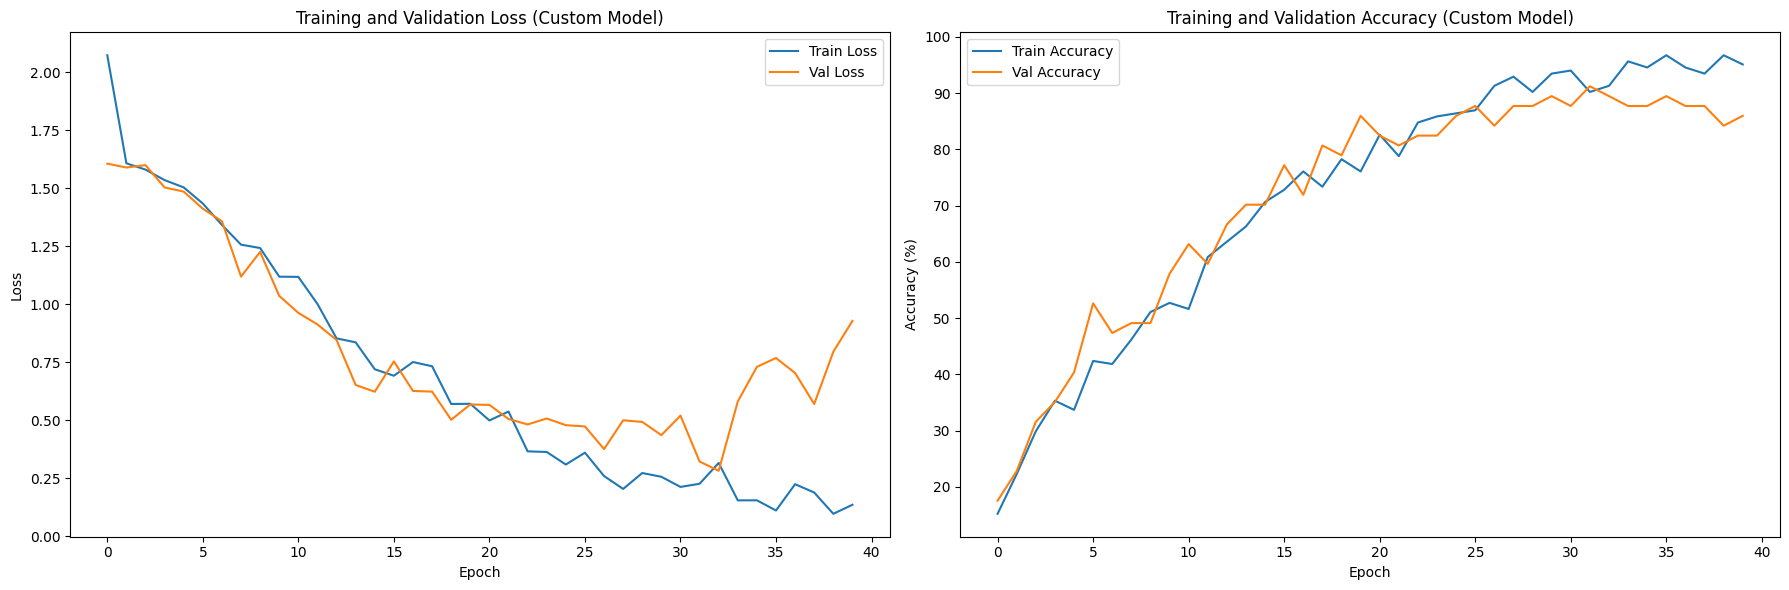

In [31]:
plt.figure(figsize=(18, 6))

# Losses
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (Custom Model)')
plt.legend()

# Accuracies
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy (Custom Model)')
plt.legend()

plt.tight_layout()
plt.show()

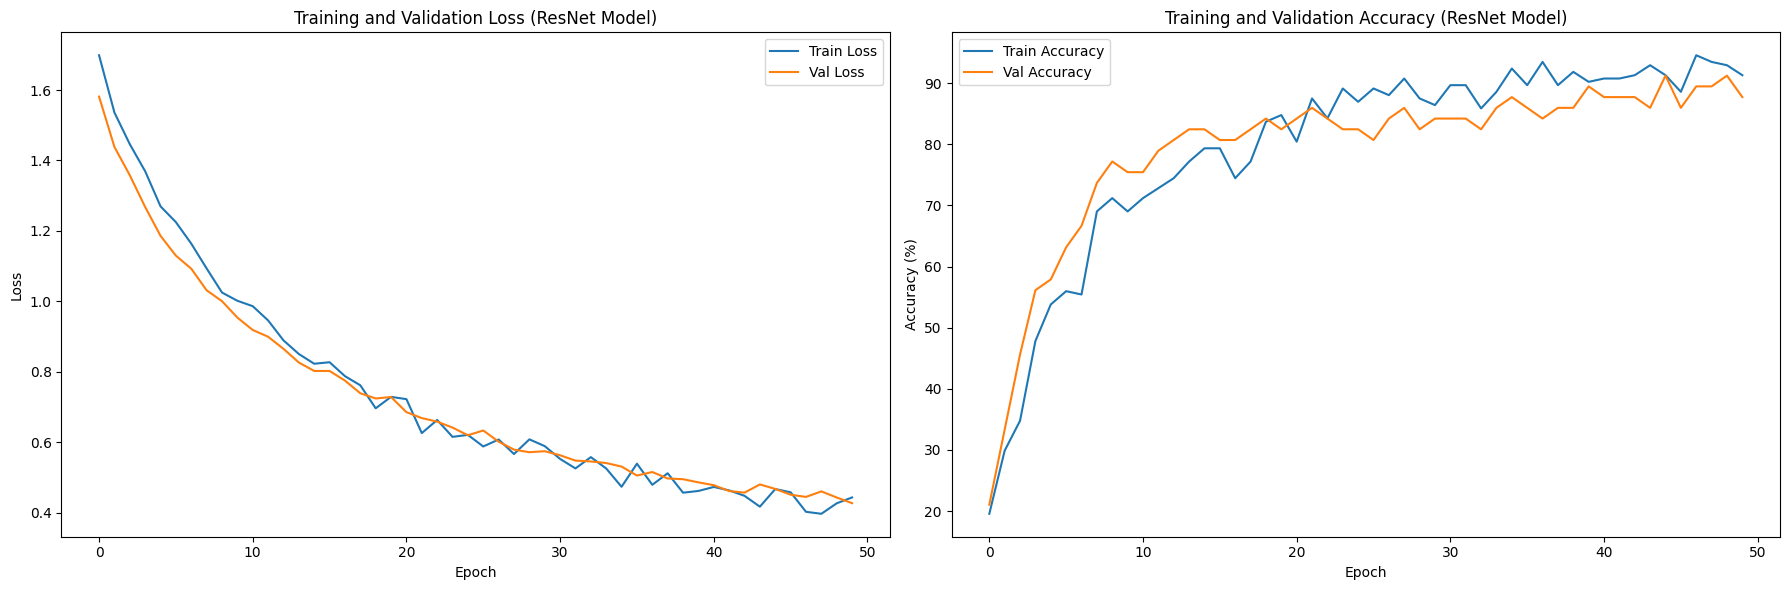

In [32]:
plt.figure(figsize=(18, 6))

# Losses
plt.subplot(1, 2, 1)
plt.plot(train_losses_resnet, label='Train Loss')
plt.plot(val_losses_resnet, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (ResNet Model)')
plt.legend()

# Accuracies
plt.subplot(1, 2, 2)
plt.plot(train_accuracies_resnet, label='Train Accuracy')
plt.plot(val_accuracies_resnet, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy (ResNet Model)')
plt.legend()

plt.tight_layout()
plt.show()

In [34]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    return accuracy

test_accuracy_custom = evaluate_model(model, test_loader)
test_accuracy_resnet = evaluate_model(resnet, test_loader)

Test Accuracy: 88.33%
Test Accuracy: 90.00%


In [47]:
def predict_and_visualize(model, image_tensor, true_label, class_names, device):
    model.eval()

    with torch.no_grad():
        # Add batch dimension and move to device
        image_tensor = image_tensor.unsqueeze(0).to(device)

        # Get model output
        outputs = model(image_tensor)

        # Convert to probabilities
        probabilities = F.softmax(outputs, dim=1)
        probs = probabilities.cpu().numpy()[0] * 100  # Convert to percentages

        # Get predicted class
        predicted_idx = torch.argmax(probabilities, dim=1).item()

    # Sort probabilities in descending order
    sorted_indices = np.argsort(probs)[::-1]

    # Create figure with image and bar chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Display image
    img = image_tensor.squeeze(0).cpu()
    # Denormalize for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    img = img.permute(1, 2, 0).numpy()

    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title(f'True Label: {class_names[true_label]}\nPredicted: {class_names[predicted_idx]}')

    # Display probabilities as horizontal bar chart
    colors = ['green' if i == predicted_idx else 'skyblue' for i in sorted_indices]
    y_pos = np.arange(len(class_names))

    ax2.barh(y_pos, probs[sorted_indices], color=colors)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([class_names[i] for i in sorted_indices])
    ax2.set_xlabel('Probability (%)')
    ax2.set_title('Prediction Probabilities')
    ax2.set_xlim([0, 100])

    # Add percentage labels on bars
    for i, (idx, prob) in enumerate(zip(sorted_indices, probs[sorted_indices])):
        ax2.text(prob + 1, i, f'{prob:.1f}%', va='center')

    plt.tight_layout()
    plt.show()

    # Print results
    print(f"Prediction Results:")
    print(f"{'='*40}")
    for idx in sorted_indices:
        symbol = "✓" if idx == predicted_idx else " "
        print(f"{symbol} {class_names[idx]:<20} {probs[idx]:>6.2f}%")
    print(f"{'='*40}")
    print(f"Correct: {'YES ✓' if predicted_idx == true_label else 'NO ✗'}\n")

Classes: ['LeBron James', 'Michael Jordan', "Shaquille O'Neal", 'Stephen Curry', 'Tim Duncan']

Custom Model


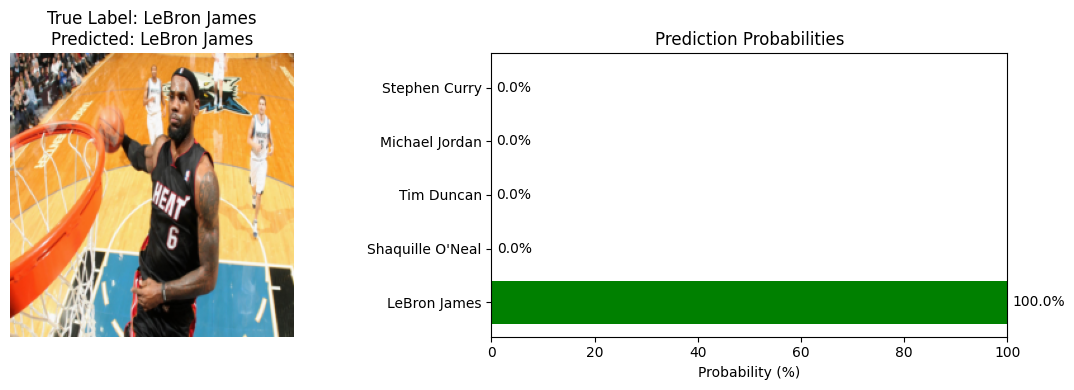

Prediction Results:
✓ LeBron James          99.97%
  Shaquille O'Neal       0.03%
  Tim Duncan             0.00%
  Michael Jordan         0.00%
  Stephen Curry          0.00%
Correct: YES ✓

ResNet Model


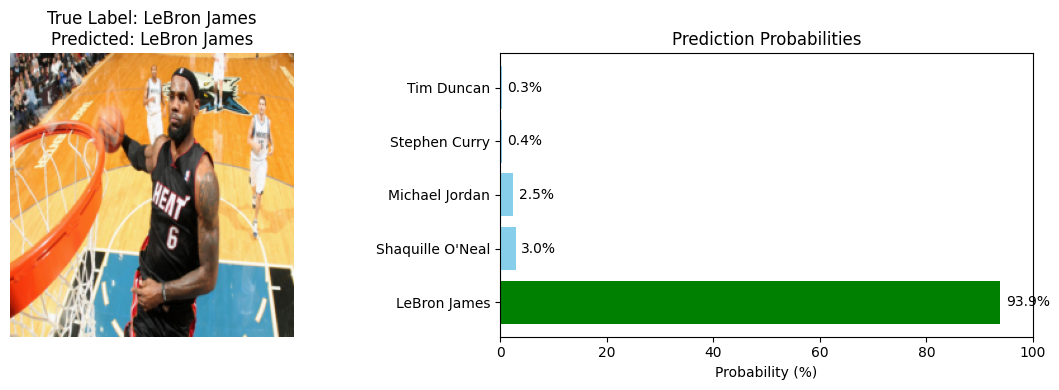

Prediction Results:
✓ LeBron James          93.86%
  Shaquille O'Neal       2.95%
  Michael Jordan         2.49%
  Stephen Curry          0.37%
  Tim Duncan             0.33%
Correct: YES ✓



In [48]:
# Class names
class_names = train_dataset.classes
print(f"Classes: {class_names}\n")

# Test on single image from test set
image, label = test_dataset[0]

print('Custom Model')
predict_and_visualize(model, image, label, class_names, device)

print('ResNet Model')
predict_and_visualize(resnet, image, label, class_names, device)


Custom Model Results:


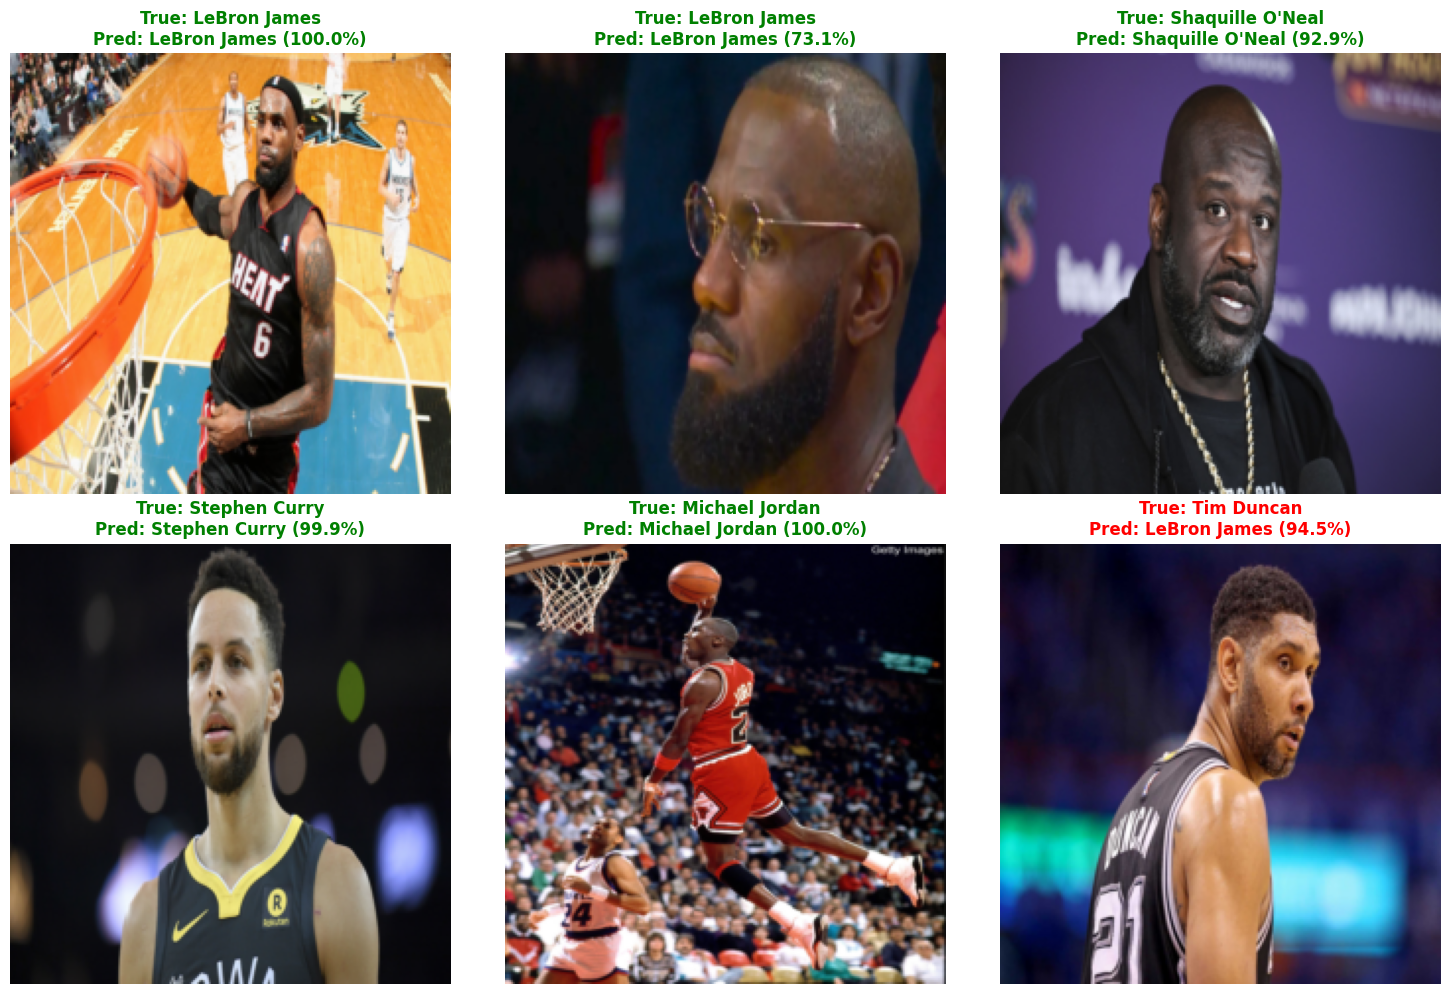

ResNet Model Results:


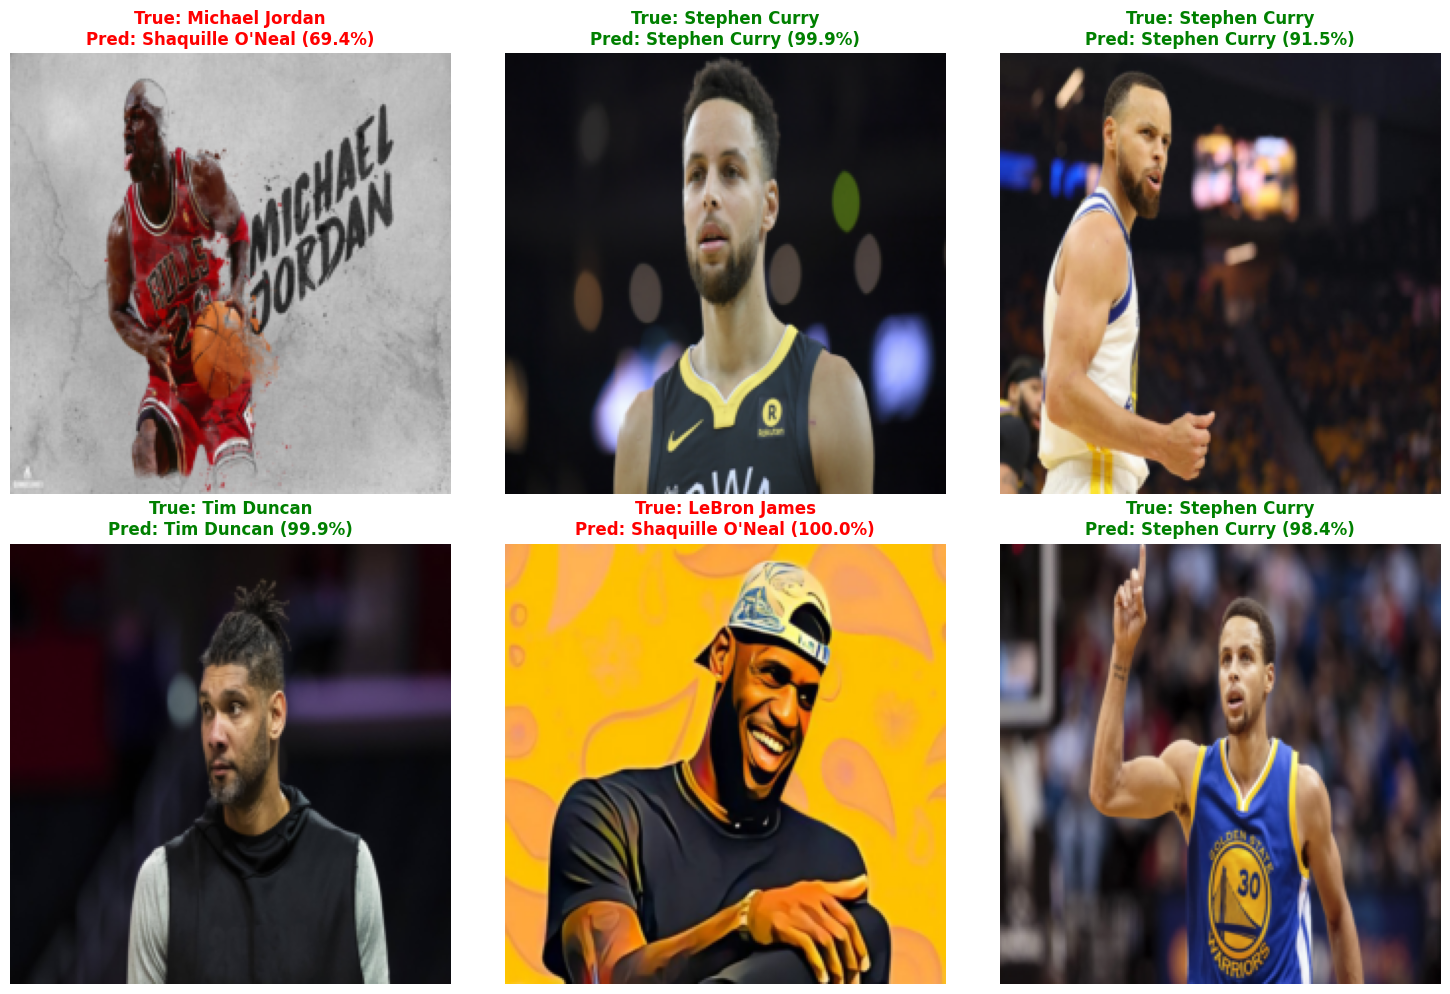

In [37]:
def show_multiple_predictions(model, dataset, class_names, device, num_images=6):
    model.eval()

    # Randomly select images
    indices = np.random.choice(len(dataset), num_images, replace=False)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for idx, img_idx in enumerate(indices):
        image, true_label = dataset[img_idx]

        with torch.no_grad():
            image_batch = image.unsqueeze(0).to(device)
            outputs = model(image_batch)
            probabilities = F.softmax(outputs, dim=1)
            probs = probabilities.cpu().numpy()[0] * 100
            predicted_idx = torch.argmax(probabilities, dim=1).item()

        # Denormalize image
        img = image.cpu()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        img = img.permute(1, 2, 0).numpy()

        # Display image
        axes[idx].imshow(img)
        axes[idx].axis('off')

        # Title with prediction info
        title = f"True: {class_names[true_label]}\n"
        title += f"Pred: {class_names[predicted_idx]} ({probs[predicted_idx]:.1f}%)"
        color = 'green' if predicted_idx == true_label else 'red'
        axes[idx].set_title(title, color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Show multiple predictions
print('Custom Model Results:')
show_multiple_predictions(model, test_dataset, class_names, device, num_images=6)

print('ResNet Model Results:')
show_multiple_predictions(model, test_dataset, class_names, device, num_images=6)

In [52]:
def calculate_average_predictions(model, dataset, player_images, class_names, device):
    model.eval()

    # Store probabilities for all images
    all_probs = []
    correct_predictions = 0

    with torch.no_grad():
        for img_idx in player_images:
            image, true_label = dataset[img_idx]
            image_batch = image.unsqueeze(0).to(device)

            outputs = model(image_batch)
            probabilities = F.softmax(outputs, dim=1)
            probs = probabilities.cpu().numpy()[0] * 100

            all_probs.append(probs)

            # Check if prediction was correct
            predicted_idx = np.argmax(probs)
            if predicted_idx == true_label:
                correct_predictions += 1

    # Calculate mean probabilities across all images
    mean_probs = np.mean(all_probs, axis=0)

    # Sort by probability
    sorted_indices = np.argsort(mean_probs)[::-1]

    # Print results
    print(f"\nAverage Prediction Results for {class_names[dataset[player_images[0]][1]]}:")
    print(f"Number of images: {len(player_images)}")
    print(f"Accuracy: {correct_predictions}/{len(player_images)} ({100*correct_predictions/len(player_images):.1f}%)")
    print(f"{'='*40}")
    for idx in sorted_indices:
        print(f"{class_names[idx]:<20} {mean_probs[idx]:>6.2f}%")
    print(f"{'='*40}")

    return mean_probs, correct_predictions

In [53]:
mean_probs, correct = calculate_average_predictions(
    model, test_dataset, curry_images, class_names, device
)


Average Prediction Results for Stephen Curry:
Number of images: 11
Accuracy: 10/11 (90.9%)
Stephen Curry         84.93%
Tim Duncan            12.99%
LeBron James           1.41%
Shaquille O'Neal       0.67%
Michael Jordan         0.00%


In [57]:
# Calculate average predictions and accuracy for each player

def analyze_all_players(model, dataset, class_names, device):
    results = {}

    for class_idx, player_name in enumerate(class_names):
        # Find all images of this player
        player_images = [i for i in range(len(dataset)) if dataset[i][1] == class_idx]

        if len(player_images) == 0:
            continue

        print(f"\n{'='*50}")
        print(f"Analyzing: {player_name}")
        print(f"{'='*50}")

        mean_probs, correct = calculate_average_predictions(
            model, dataset, player_images, class_names, device
        )

        results[player_name] = {
            'mean_probs': mean_probs,
            'accuracy': correct / len(player_images) * 100,
            'num_images': len(player_images),
            'correct_predictions': correct
        }

    return results

# Run analysis
all_results_custom = analyze_all_players(model, test_dataset, class_names, device)
all_results_resnet = analyze_all_players(resnet, test_dataset, class_names, device)


Analyzing: LeBron James

Average Prediction Results for LeBron James:
Number of images: 13
Accuracy: 11/13 (84.6%)
LeBron James          79.56%
Tim Duncan             9.08%
Shaquille O'Neal       8.42%
Stephen Curry          2.45%
Michael Jordan         0.50%

Analyzing: Michael Jordan

Average Prediction Results for Michael Jordan:
Number of images: 14
Accuracy: 13/14 (92.9%)
Michael Jordan        94.46%
Shaquille O'Neal       5.14%
LeBron James           0.27%
Tim Duncan             0.12%
Stephen Curry          0.00%

Analyzing: Shaquille O'Neal

Average Prediction Results for Shaquille O'Neal:
Number of images: 10
Accuracy: 8/10 (80.0%)
Shaquille O'Neal      83.86%
LeBron James          10.23%
Michael Jordan         4.27%
Tim Duncan             1.50%
Stephen Curry          0.14%

Analyzing: Stephen Curry

Average Prediction Results for Stephen Curry:
Number of images: 11
Accuracy: 10/11 (90.9%)
Stephen Curry         84.93%
Tim Duncan            12.99%
LeBron James           1.41%
S

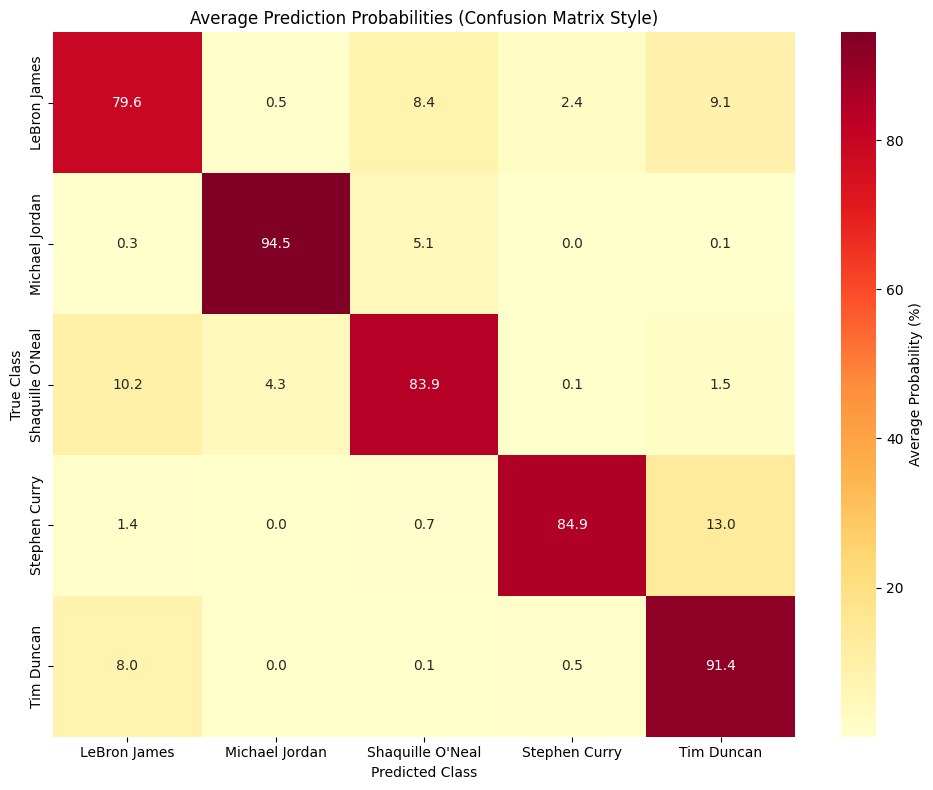

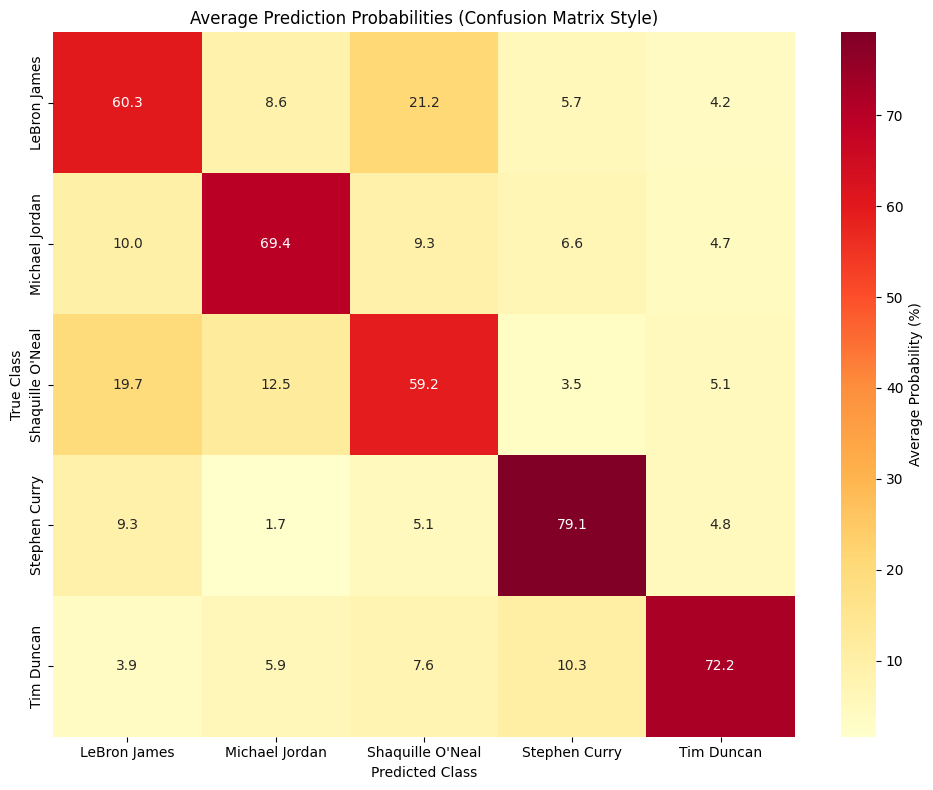

In [59]:
def visualize_average_predictions(results, class_names):

    # Create matrix: rows = true player, columns = predicted player
    matrix = np.zeros((len(class_names), len(class_names)))

    for i, player in enumerate(class_names):
        if player in results:
            matrix[i] = results[player]['mean_probs']

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Average Probability (%)'})
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.title('Average Prediction Probabilities (Confusion Matrix Style)')
    plt.tight_layout()
    plt.show()

# Visualize results
visualize_average_predictions(all_results_custom, class_names)
visualize_average_predictions(all_results_resnet, class_names)